Title: LEE_ERA5_Results_specific_event.ipynb

Purpose: Look at an exemplary event in the ERA5 data

Author: Onno Nennecke on 29.08.2025 Modified: 11.09.2025

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'
- adjusted final model output
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'


Output data:

- Event TS Plots: Event_2017_TS, Event_2024_TS
    - These files lie here: /home/onennecke/Code/Figures/

In [ ]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import os
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from datetime import datetime, timedelta


### Read LEE data

In [2]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


### Filter for ERA5 LEE data

In [3]:
# Remove all CMIP data from the LEE_dat DataFrame
LEE_dat_non_CMIP = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week') | (LEE_dat['ESM'] == 'ERA5_wwd') | (LEE_dat['ESM'] == 'SMARD')]
LEE_7_non_CMIP = LEE_7[(LEE_7['ESM'] == 'ERA5_week') | (LEE_7['ESM'] == 'ERA5_wwd') | (LEE_7['ESM'] == 'SMARD')]
LEE_14_non_CMIP = LEE_14[(LEE_14['ESM'] == 'ERA5_week') | (LEE_14['ESM'] == 'ERA5_wwd') | (LEE_14['ESM'] == 'SMARD')]
LEE_vl_non_CMIP = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week') | (LEE_vl['ESM'] == 'ERA5_wwd') | (LEE_vl['ESM'] == 'SMARD')]

# Pure ERA5 data
LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')]
LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_week')]
LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_week')]
LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')]

### Pick events

### Long event (1 week)

In [4]:
LEE_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-12-11,2015-12-17,2015-12-11 00:00:00.000000005,344,350,349,7,1537.778924,1404.602138,109.037426,9832.214968,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,345
1,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000001,719,725,720,7,1502.845828,1448.824302,55.285408,10141.770116,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
2,2017-11-27,2017-12-03,2017-11-27 00:00:00.000000001,1060,1066,1061,7,1500.833281,1403.926578,75.104923,9827.486045,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,331
3,2017-12-01,2017-12-07,2017-12-01 00:00:00.000000005,1064,1070,1069,7,1483.982184,1420.771437,42.096442,9945.400059,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,335
4,2018-01-18,2018-01-24,2018-01-18 00:00:00.000000002,1112,1118,1114,7,1479.508737,1426.710531,69.408603,9986.973719,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,2023-01-24,2023-01-30,2023-01-24 00:00:00.000000002,2943,2949,2945,7,1493.480853,1407.710098,88.175757,9853.970686,1140,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,24
1140,2024-11-05,2024-11-11,2024-11-05 00:00:00.000000005,3593,3599,3598,7,1434.148158,1403.884956,24.601696,9827.194690,1141,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,309
1141,2024-11-10,2024-11-16,2024-11-10 00:00:00.000000006,3598,3604,3604,7,1468.658163,1407.040411,40.182743,9849.282876,1142,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,314
1142,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000001,18,24,19,7,1567.507000,1432.481214,160.806691,10027.368500,1143,SMARD,SMARD_hist,2015,19


In [5]:
LEE_7[(LEE_7['ESM'] == 'ERA5_week')]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
550,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000004,18,24,22,7,1497.249011,1449.366519,46.744941,10145.565631,551,ERA5_week,ERA5_hist_week,2015,19
551,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1502.737606,1456.367093,32.641307,10194.569654,552,ERA5_week,ERA5_hist_week,2016,15
552,2016-12-14,2016-12-20,2016-12-14 00:00:00.000000003,712,718,715,7,1458.652965,1415.033120,53.764337,9905.231838,553,ERA5_week,ERA5_hist_week,2016,348
553,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1541.727728,1478.688488,49.626313,10350.819414,554,ERA5_week,ERA5_hist_week,2017,19
554,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1542.347000,1450.622709,86.209183,10154.358961,555,ERA5_week,ERA5_hist_week,2019,19
555,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1470.258197,1424.666513,40.762916,9972.665588,556,ERA5_week,ERA5_hist_week,2020,330
556,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1554.145256,1492.080803,26.066980,10444.565622,557,ERA5_week,ERA5_hist_week,2022,344
557,2023-01-20,2023-01-26,2023-01-20 00:00:00.000000000,2939,2945,2939,7,1502.508759,1411.341731,74.062268,9879.392118,558,ERA5_week,ERA5_hist_week,2023,20
558,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000006,2941,2947,2947,7,1460.861030,1418.133334,51.195259,9926.933336,559,ERA5_week,ERA5_hist_week,2023,22
559,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000005,3250,3256,3255,7,1540.015423,1450.126204,77.766638,10150.883425,560,ERA5_week,ERA5_hist_week,2023,331


In [6]:
LEE_vl[(LEE_vl['ESM'] == 'ERA5_wwd')][140:150]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
5381,2024-01-17,2024-01-18,2024-01-17 00:00:00.000000000,3301,3302,3301,2,1466.278102,1460.218221,6.059880,2920.436443,5382,ERA5_wwd,ERA5_hist_wwd,2024,17
5382,2024-02-08,2024-02-08,2024-02-08 00:00:00.000000000,3323,3323,3323,1,1479.437341,1479.437341,0.000000,1479.437341,5383,ERA5_wwd,ERA5_hist_wwd,2024,39
5383,2024-02-27,2024-02-27,2024-02-27 00:00:00.000000000,3342,3342,3342,1,1425.230363,1425.230363,0.000000,1425.230363,5384,ERA5_wwd,ERA5_hist_wwd,2024,58
5384,2024-03-12,2024-03-12,2024-03-12 00:00:00.000000000,3355,3355,3355,1,1398.526241,1398.526241,0.000000,1398.526241,5385,ERA5_wwd,ERA5_hist_wwd,2024,71
5385,2024-11-04,2024-11-07,2024-11-04 00:00:00.000000003,3592,3595,3595,4,1504.718685,1477.291484,24.737551,5909.165937,5386,ERA5_wwd,ERA5_hist_wwd,2024,308
5386,2024-11-11,2024-11-13,2024-11-11 00:00:00.000000001,3599,3601,3600,3,1470.530233,1458.748136,9.610479,4376.244409,5387,ERA5_wwd,ERA5_hist_wwd,2024,315
5387,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1508.149164,1508.149164,0.000000,1508.149164,5388,ERA5_wwd,ERA5_hist_wwd,2024,333
5388,2024-12-04,2024-12-04,2024-12-04 00:00:00.000000000,3622,3622,3622,1,1481.906900,1481.906900,0.000000,1481.906900,5389,ERA5_wwd,ERA5_hist_wwd,2024,338
5389,2024-12-11,2024-12-13,2024-12-11 00:00:00.000000001,3629,3631,3630,3,1569.629871,1562.641732,7.751304,4687.925196,5390,ERA5_wwd,ERA5_hist_wwd,2024,345
5390,2024-12-24,2024-12-27,2024-12-24 00:00:00.000000003,3642,3645,3645,4,1564.638061,1494.101654,54.469760,5976.406615,5391,ERA5_wwd,ERA5_hist_wwd,2024,358


In [7]:
LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')][80:90]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
5229,2023-11-28,2023-11-28,2023-11-28 00:00:00.000000000,3251,3251,3251,1,1479.973280,1479.973280,0.000000,1479.973280,5230,ERA5_week,ERA5_hist_week,2023,332
5230,2023-11-30,2023-12-03,2023-11-30 00:00:00.000000002,3253,3256,3255,4,1540.015423,1499.532897,37.992377,5998.131587,5231,ERA5_week,ERA5_hist_week,2023,334
5231,2023-12-07,2023-12-07,2023-12-07 00:00:00.000000000,3260,3260,3260,1,1491.578370,1491.578370,0.000000,1491.578370,5232,ERA5_week,ERA5_hist_week,2023,341
5232,2023-12-14,2023-12-14,2023-12-14 00:00:00.000000000,3267,3267,3267,1,1467.983933,1467.983933,0.000000,1467.983933,5233,ERA5_week,ERA5_hist_week,2023,348
5233,2024-01-10,2024-01-11,2024-01-10 00:00:00.000000001,3294,3295,3295,2,1488.794867,1484.022393,4.772474,2968.044787,5234,ERA5_week,ERA5_hist_week,2024,10
5234,2024-02-08,2024-02-08,2024-02-08 00:00:00.000000000,3323,3323,3323,1,1402.240585,1402.240585,0.000000,1402.240585,5235,ERA5_week,ERA5_hist_week,2024,39
5235,2024-11-06,2024-11-07,2024-11-06 00:00:00.000000001,3594,3595,3595,2,1427.796599,1424.949553,2.847046,2849.899106,5236,ERA5_week,ERA5_hist_week,2024,310
5236,2024-11-10,2024-11-10,2024-11-10 00:00:00.000000000,3598,3598,3598,1,1412.311720,1412.311720,0.000000,1412.311720,5237,ERA5_week,ERA5_hist_week,2024,314
5237,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1430.343242,1430.343242,0.000000,1430.343242,5238,ERA5_week,ERA5_hist_week,2024,333
5238,2024-12-04,2024-12-04,2024-12-04 00:00:00.000000000,3622,3622,3622,1,1404.000548,1404.000548,0.000000,1404.000548,5239,ERA5_week,ERA5_hist_week,2024,338


### Short event 1-2 days

In [8]:
LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')][170:180]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
9666,2024-01-11,2024-01-11,2024-01-11,3295,3295,3295,1,1488.794867,1488.794867,0.0,1488.794867,9667,ERA5_week,ERA5_hist_week,2024,11
9667,2024-02-08,2024-02-08,2024-02-08,3323,3323,3323,1,1402.240585,1402.240585,0.0,1402.240585,9668,ERA5_week,ERA5_hist_week,2024,39
9668,2024-11-06,2024-11-06,2024-11-06,3594,3594,3594,1,1422.102507,1422.102507,0.0,1422.102507,9669,ERA5_week,ERA5_hist_week,2024,310
9669,2024-11-07,2024-11-07,2024-11-07,3595,3595,3595,1,1427.796599,1427.796599,0.0,1427.796599,9670,ERA5_week,ERA5_hist_week,2024,311
9670,2024-11-10,2024-11-10,2024-11-10,3598,3598,3598,1,1412.311720,1412.311720,0.0,1412.311720,9671,ERA5_week,ERA5_hist_week,2024,314
9671,2024-11-29,2024-11-29,2024-11-29,3617,3617,3617,1,1430.343242,1430.343242,0.0,1430.343242,9672,ERA5_week,ERA5_hist_week,2024,333
9672,2024-12-04,2024-12-04,2024-12-04,3622,3622,3622,1,1404.000548,1404.000548,0.0,1404.000548,9673,ERA5_week,ERA5_hist_week,2024,338
9673,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1488.280916,1488.280916,0.0,1488.280916,9674,ERA5_week,ERA5_hist_week,2024,345
9674,2024-12-12,2024-12-12,2024-12-12,3630,3630,3630,1,1491.259356,1491.259356,0.0,1491.259356,9675,ERA5_week,ERA5_hist_week,2024,346
9675,2024-12-13,2024-12-13,2024-12-13,3631,3631,3631,1,1473.156796,1473.156796,0.0,1473.156796,9676,ERA5_week,ERA5_hist_week,2024,347


In [9]:
LEE_dat[(LEE_dat['ESM'] == 'SMARD')]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
18514,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1502.90425,1502.90425,0.0,1502.90425,18515,SMARD,SMARD_hist,2015,19
18515,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1567.50700,1567.50700,0.0,1567.50700,18516,SMARD,SMARD_hist,2015,20
18516,2015-01-21,2015-01-21,2015-01-21,20,20,20,1,1524.69225,1524.69225,0.0,1524.69225,18517,SMARD,SMARD_hist,2015,21
18517,2015-01-22,2015-01-22,2015-01-22,21,21,21,1,1529.50250,1529.50250,0.0,1529.50250,18518,SMARD,SMARD_hist,2015,22
18518,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1537.33700,1537.33700,0.0,1537.33700,18519,SMARD,SMARD_hist,2015,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18600,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.21775,1433.21775,0.0,1433.21775,18601,SMARD,SMARD_hist,2022,25
18601,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.19450,1446.19450,0.0,1446.19450,18602,SMARD,SMARD_hist,2023,334
18602,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.96600,1409.96600,0.0,1409.96600,18603,SMARD,SMARD_hist,2023,335
18603,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.07550,1425.07550,0.0,1425.07550,18604,SMARD,SMARD_hist,2024,345


---

In [10]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
files = [path]

ds = xr.open_dataset(path)

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ds_ERA5.load()

ds_ERA5_wwd = ds.where((ds.ESM_run == 'ERA5_hist_wwd'),drop=True)
ds_ERA5_wwd.load()

ds_SMARD = ds.where(ds.ESM_run == 'SMARD_hist', drop=True)
ds_SMARD.load()
# ts_datasets

<xarray.Dataset> Size: 482kB
Dimensions:            (ESM_run: 1, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 52B 'SMARD'
    run                (ESM_run) <U10 40B 'hist'
  * ESM_run            (ESM_run) <U23 92B 'SMARD_hist'
    country            float64 8B 9.0
    period             (ESM_run) <U4 16B 'wwd'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/16)
    temp               (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    demand             (ESM_run, time) float64 29kB 1.097e+03 ... 1.204e+03
    sfcWind            (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    rsds               (ESM_run, time) float32 15kB nan nan nan ... nan nan nan
    tas                (ESM_run, time) float32 15kB nan nan nan ... nan nan nan
    tasmax             (ESM_run, time) float32 15kB nan nan nan ... nan nan nan
    ...                 ...
    Netto              (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    Residual_load      (ESM_run, time) float64 29kB 768.5 679.2 ... 659.8 556.8
    solar_prod_adj     (ESM_run, time) float64 29kB 17.08 7.759 ... 22.93 49.09
    total_prod_adj     (ESM_run, time) float64 29kB 328.4 609.7 ... 618.5 647.4
    Netto_adjusted     (ESM_run, time) float64 29kB nan nan nan ... nan nan nan
    Residual_load_adj  (ESM_run, time) float64 29kB 768.5 679.2 ... 659.8 556.8

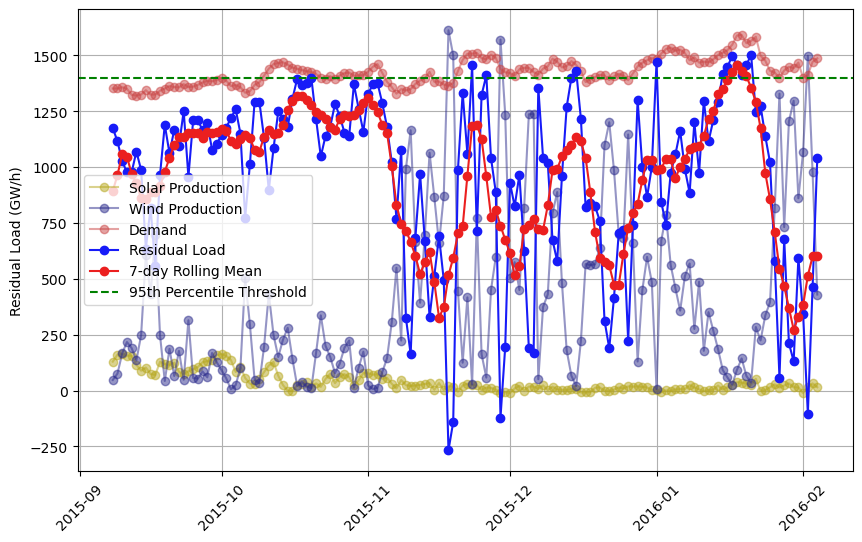

In [11]:
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=True).mean()
solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

start = 250
box = 150
threshold = np.quantile(RL.values.flatten(), 0.95)

# Extract the data for the specified range
RL_plot = RL.sel(ESM_run='ERA5_hist_week')[start: start+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run='ERA5_hist_week')[start: start+box]
solar = solar.sel(ESM_run='ERA5_hist_week')[start: start+box]
wind = wind.sel(ESM_run='ERA5_hist_week')[start: start+box]
demand = demand.sel(ESM_run='ERA5_hist_week')[start: start+box]



# Plot using matplotlib
plt.figure(figsize=(10, 6))

plt.plot(RL_plot['time'], solar, marker='o', linestyle='-', color="#B6A71E", alpha = 0.5, label='Solar Production')
plt.plot(RL_plot['time'], wind, marker='o', linestyle='-', color="#2D2D8D", alpha = 0.5, label='Wind Production')
plt.plot(RL_plot['time'], demand, marker='o', linestyle='-', color="#CA4747", alpha = 0.5, label='Demand')

plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')
# plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Residual Load (GW/h)')
# plt.title(f'Residual Load Time Series for run: {LEE["ESM_run"][evt]}')
plt.legend()
plt.grid(True)
plt.show()

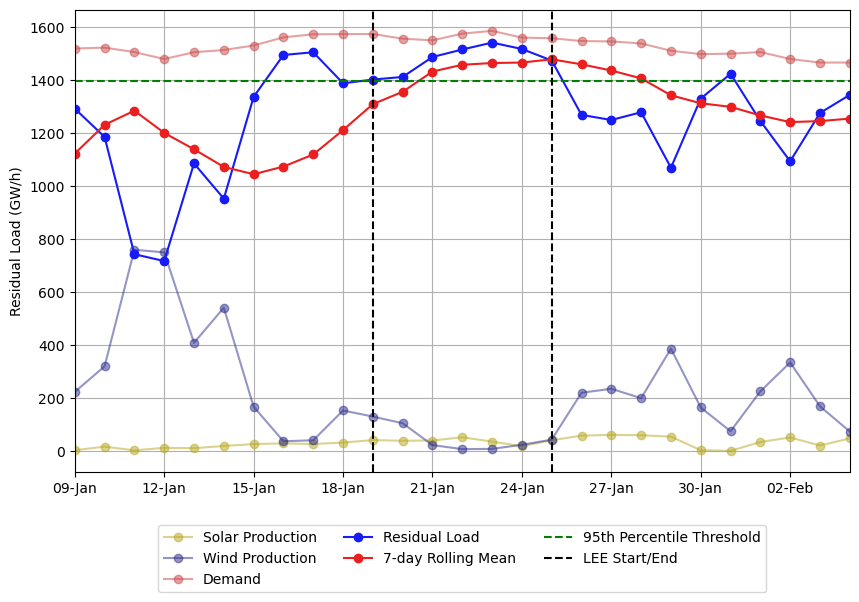

In [12]:
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()

solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

LEE = LEE_7_ERA5
evt = 553
box = 10
threshold = np.quantile(RL.values.flatten(), 0.95)

# Extract the data for the specified range
RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot_14 = RL_mov_avg_14.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]

solar = solar.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
wind = wind.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
demand = demand.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]



plt.figure(figsize=(10, 6))

plt.plot(RL_plot['time'], solar, marker='o', linestyle='-', color="#B6A71E", alpha=0.5, label='Solar Production')
plt.plot(RL_plot['time'], wind, marker='o', linestyle='-', color="#2D2D8D", alpha=0.5, label='Wind Production')
plt.plot(RL_plot['time'], demand, marker='o', linestyle='-', color="#CA4747", alpha=0.5, label='Demand')

plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
# plt.plot(rolling_mean_plot_14['time'], rolling_mean_plot_14, marker='o', linestyle='-', color="#F5A623", label='14-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

plt.axvline(x=RL_plot['time'].isel(time=box).values, color='k', linestyle='--', label='LEE Start/End')
plt.axvline(x=RL_plot['time'].isel(time=box+6).values, color='k', linestyle='--')


# Set xticks at regular intervals
xticks = RL_plot['time'][::3]
xtick_labels = [pd.to_datetime(str(t)).strftime('%d-%b') for t in xticks.values]
plt.xticks(xticks, labels=xtick_labels, rotation=0)
plt.xlim(RL_plot['time'].min(), RL_plot['time'].max())
plt.ylabel('Residual Load (GW/h)')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/Event_2017_TS.png', bbox_inches='tight', dpi=300)


plt.show()

In [13]:
RL_plot['time'][box]

<xarray.DataArray 'time' ()> Size: 8B
array('2017-01-19T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    time      datetime64[ns] 8B 2017-01-19
    ESM       <U13 52B 'ERA5_week'
    run       <U10 40B 'hist'
    ESM_run   <U23 92B 'ERA5_hist_week'
    country   float64 8B 9.0
    period    <U4 16B 'week'
    doy       int64 8B 19

In [14]:
LEE_vl_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
5149,2015-01-19,2015-01-24,2015-01-19 00:00:00.000000004,18,23,22,6,1497.249011,1465.148179,28.387418,8790.889073,5150,ERA5_week,ERA5_hist_week,2015,19
5150,2015-01-30,2015-01-30,2015-01-30 00:00:00.000000000,29,29,29,1,1412.344556,1412.344556,0.000000,1412.344556,5151,ERA5_week,ERA5_hist_week,2015,30
5151,2015-02-04,2015-02-04,2015-02-04 00:00:00.000000000,34,34,34,1,1449.191276,1449.191276,0.000000,1449.191276,5152,ERA5_week,ERA5_hist_week,2015,35
5152,2015-02-11,2015-02-12,2015-02-11 00:00:00.000000000,41,42,41,2,1424.867738,1423.959088,0.908651,2847.918175,5153,ERA5_week,ERA5_hist_week,2015,42
5153,2015-02-17,2015-02-17,2015-02-17 00:00:00.000000000,47,47,47,1,1422.471565,1422.471565,0.000000,1422.471565,5154,ERA5_week,ERA5_hist_week,2015,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236,2024-11-10,2024-11-10,2024-11-10 00:00:00.000000000,3598,3598,3598,1,1412.311720,1412.311720,0.000000,1412.311720,5237,ERA5_week,ERA5_hist_week,2024,314
5237,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1430.343242,1430.343242,0.000000,1430.343242,5238,ERA5_week,ERA5_hist_week,2024,333
5238,2024-12-04,2024-12-04,2024-12-04 00:00:00.000000000,3622,3622,3622,1,1404.000548,1404.000548,0.000000,1404.000548,5239,ERA5_week,ERA5_hist_week,2024,338
5239,2024-12-11,2024-12-13,2024-12-11 00:00:00.000000001,3629,3631,3630,3,1491.259356,1484.232356,7.925435,4452.697068,5240,ERA5_week,ERA5_hist_week,2024,345


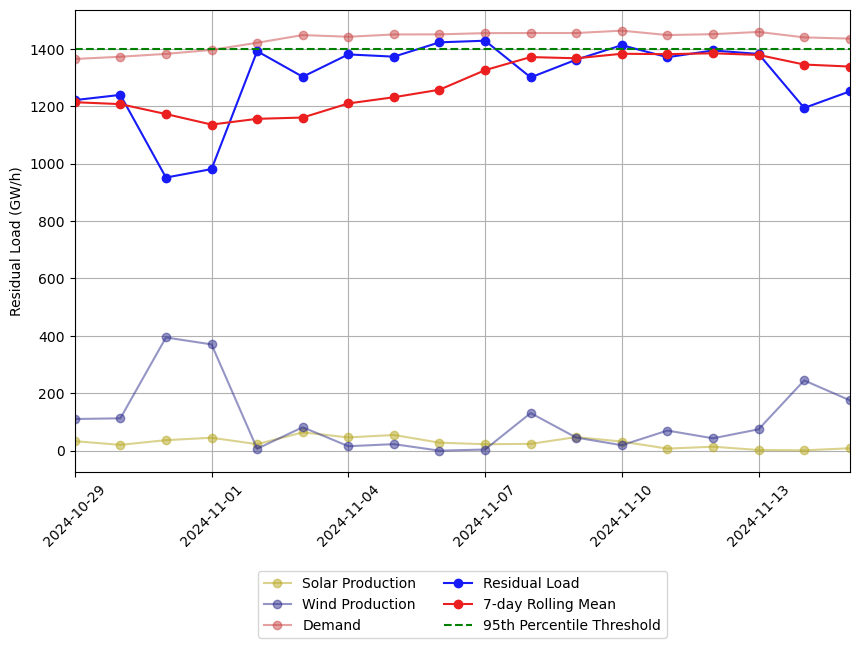

In [15]:
RL = ds_ERA5['Residual_load_adj']
RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
solar = ds_ERA5['solar_prod_adj']
wind = ds_ERA5['wind_on_prod'] + ds_ERA5['wind_off_prod']
demand = ds_ERA5['demand']

LEE = LEE_vl_ERA5
evt = 5235
box = 8
threshold = np.quantile(RL.values.flatten(), 0.95)

# Extract the data for the specified range
RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
solar = solar.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
wind = wind.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
demand = demand.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]



# Plot using matplotlib
plt.figure(figsize=(10, 6))

plt.plot(RL_plot['time'], solar, marker='o', linestyle='-', color="#B6A71E", alpha=0.5, label='Solar Production')
plt.plot(RL_plot['time'], wind, marker='o', linestyle='-', color="#2D2D8D", alpha=0.5, label='Wind Production')
plt.plot(RL_plot['time'], demand, marker='o', linestyle='-', color="#CA4747", alpha=0.5, label='Demand')

plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color="#171BF8", label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color="#EB1F1F", label='7-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')

# Set xticks at regular intervals
xticks = RL_plot['time'][::3]
plt.xticks(xticks, rotation=45)
plt.xlim(RL_plot['time'].min(), RL_plot['time'].max())
plt.ylabel('Residual Load (GW/h)')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# plt.savefig('/home/onennecke/Code/Figures/Event_2024_TS.png', bbox_inches='tight', dpi=300)

plt.show()

### Plot anomaly maps

In [17]:
def setup_gridlines(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 14):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [18]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

# files = sorted(glob.glob(os.path.join(path, '*.nc')))
# ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

# ts_datasets


# Open this: ERA5_hist_psl_anomaly.nc
ts_datasets = xr.open_dataset('/climca/people/onennecke/model_output/psl_anomaly/not_bc/ERA5_hist_psl_anomaly.nc')
ts_datasets

<xarray.Dataset> Size: 15MB
Dimensions:   (time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
    ESM       <U4 16B ...
    run       <U4 16B ...
    ESM_run   <U9 36B ...
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    psl       (time, lat, lon) float32 15MB ...
Attributes:
    regrid_method:  bilinear

In [19]:
LEE_dat_ERA5
LEE_7_ERA5['date_start'].iloc[3]

'2017-01-19'

In [20]:
LEE_7_ERA5

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
550,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000004,18,24,22,7,1497.249011,1449.366519,46.744941,10145.565631,551,ERA5_week,ERA5_hist_week,2015,19
551,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1502.737606,1456.367093,32.641307,10194.569654,552,ERA5_week,ERA5_hist_week,2016,15
552,2016-12-14,2016-12-20,2016-12-14 00:00:00.000000003,712,718,715,7,1458.652965,1415.033120,53.764337,9905.231838,553,ERA5_week,ERA5_hist_week,2016,348
553,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1541.727728,1478.688488,49.626313,10350.819414,554,ERA5_week,ERA5_hist_week,2017,19
554,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1542.347000,1450.622709,86.209183,10154.358961,555,ERA5_week,ERA5_hist_week,2019,19
555,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1470.258197,1424.666513,40.762916,9972.665588,556,ERA5_week,ERA5_hist_week,2020,330
556,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1554.145256,1492.080803,26.066980,10444.565622,557,ERA5_week,ERA5_hist_week,2022,344
557,2023-01-20,2023-01-26,2023-01-20 00:00:00.000000000,2939,2945,2939,7,1502.508759,1411.341731,74.062268,9879.392118,558,ERA5_week,ERA5_hist_week,2023,20
558,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000006,2941,2947,2947,7,1460.861030,1418.133334,51.195259,9926.933336,559,ERA5_week,ERA5_hist_week,2023,22
559,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000005,3250,3256,3255,7,1540.015423,1450.126204,77.766638,10150.883425,560,ERA5_week,ERA5_hist_week,2023,331


/tmp/ipykernel_238139/1572955181.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


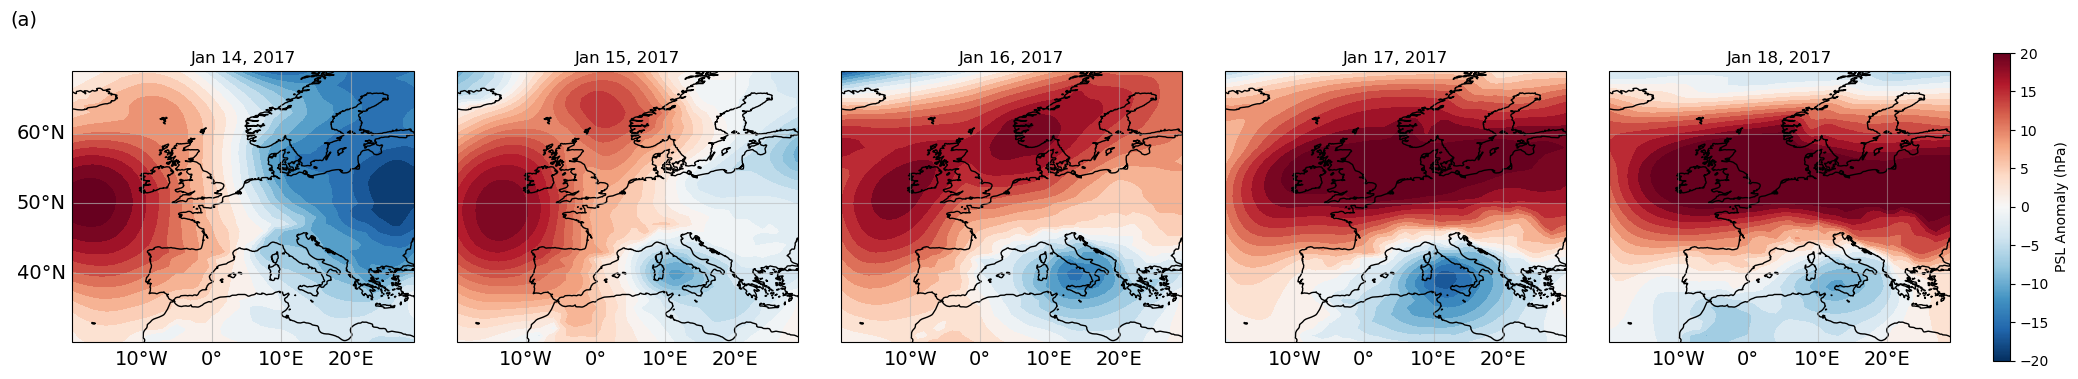

In [23]:

target_date = pd.to_datetime(LEE_7_ERA5['date_start'].iloc[3])
n_days = 5
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(n_days, 0, -1)]
# print("dates_to_plot =", dates_to_plot)

cmap_name = "RdBu_r"

# --- select slices from xarray Dataset/DataArray (assumes ts_datasets is an xarray dataset) ---
psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')  # returns DataArray

# convert to numpy and detect units (Pa vs hPa). If values are large (>2000) assume Pa -> divide by 100
psl_slices_hpa = psl_sel.values / 100  # shape expected (ntime, nlat, nlon)

# --- prepare lon/lat grids ---
lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
# ensure ordering of lat/lon matches psl array (psl likely lat x lon)
# print("lon shape", lon_vals.shape, "lat shape", lat_vals.shape)
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)  # Lon2d,Lat2d shapes: (nlat, nlon)

# --- plotting ---
ncols = psl_slices_hpa.shape[0]  # number of times (should be n_days)
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

vmin = np.nanmin(psl_slices_hpa)
vmax = -vmin

cmap_used = None
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    z = psl_slices_hpa[i, :, :]  

    cf = ax.contourf(
        Lon2d, Lat2d, z,
        levels=21, vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()

    setup_gridlines(ax, deg=10, alpha=0.7 if i==0 else 0.5, ll=(i==0))

    title_time = dates_to_plot[i]

    ax.set_title(pd.to_datetime(title_time).strftime("%b %d, %Y"), fontsize=12)

# (a) label
fig.text(0.1, 0.95, "(a)", fontsize=14)

# colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save plot
plt.savefig('/home/onennecke/Code/Figures/Event_2017_PSL.png', bbox_inches='tight', dpi=300)

plt.show()


/tmp/ipykernel_934888/1956316261.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


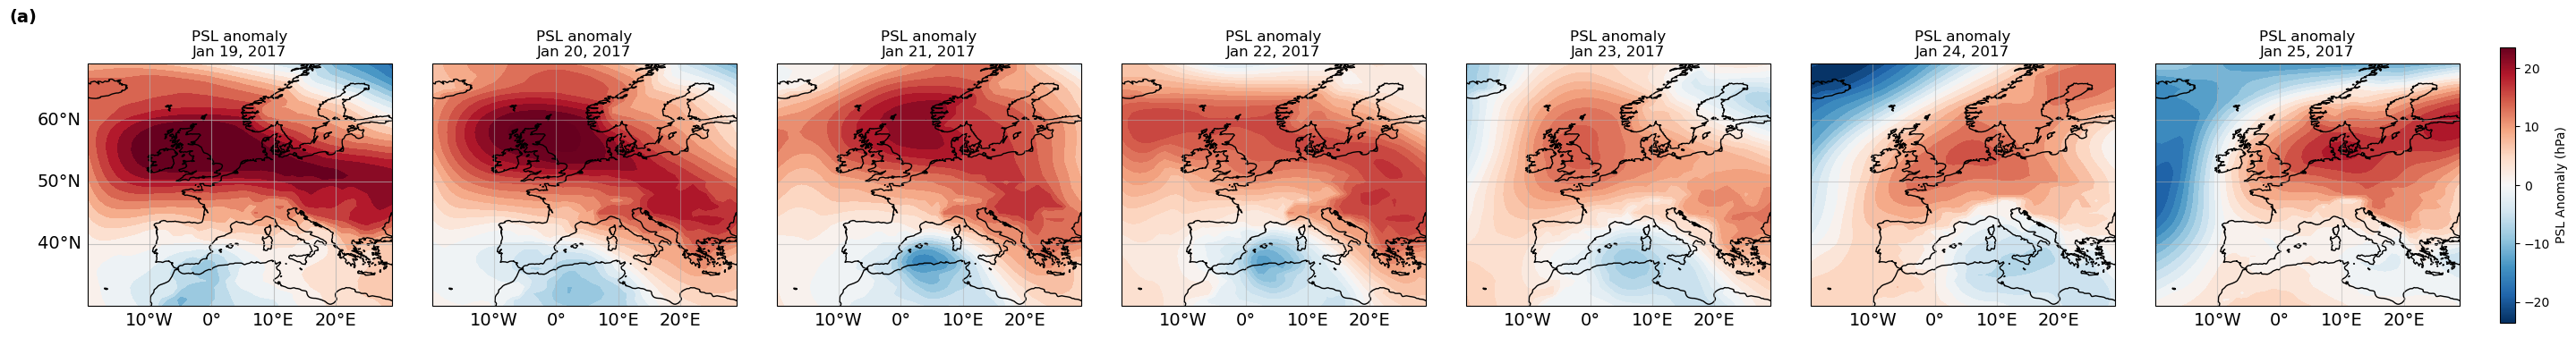

In [31]:
# --- choose target and 7-day window (includes target_date) ---
target_date = pd.to_datetime(LEE_7_ERA5['date_start'].iloc[3])
n_days = 7
dates_to_plot = pd.date_range(start=target_date, periods=n_days).tolist()
# print("dates_to_plot =", dates_to_plot)

cmap_name = "RdBu_r"

# --- select slices from xarray Dataset/DataArray (assumes ts_datasets is an xarray dataset) ---
psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')  # returns DataArray

# convert to numpy and detect units (Pa vs hPa). If values are large (>2000) assume Pa -> divide by 100
psl_slices_hpa = psl_sel.values / 100  # shape expected (ntime, nlat, nlon)

# --- prepare lon/lat grids ---
lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)  # Lon2d,Lat2d shapes: (nlat, nlon)

# --- plotting ---
ncols = psl_slices_hpa.shape[0]  # should now be 7
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

vmin = np.nanmin(psl_slices_hpa)
vmax = -vmin

cmap_used = None
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    z = psl_slices_hpa[i, :, :]

    cf = ax.contourf(
        Lon2d, Lat2d, z,
        levels=21, vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()

    setup_gridlines(ax, deg=10, alpha=0.7 if i==0 else 0.5, ll=(i==0))

    title_time = dates_to_plot[i]
    ax.set_title(pd.to_datetime(title_time).strftime("PSL anomaly\n%b %d, %Y"), fontsize=12)

# (a) label
fig.text(0.1, 0.95, "(a)", fontsize=14, fontweight='bold')

# colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [21]:
LEE_vl_ERA5[80:90]
LEE_dat_ERA5[172:173]
# evt = 5235
LEE_dat_ERA5['date_start'].iloc[172]

'2024-11-06'

In [22]:
dates_to_plot

[Timestamp('2017-01-14 00:00:00'),
 Timestamp('2017-01-15 00:00:00'),
 Timestamp('2017-01-16 00:00:00'),
 Timestamp('2017-01-17 00:00:00'),
 Timestamp('2017-01-18 00:00:00')]

In [29]:
[target_date - pd.Timedelta(days=d) for d in range(n_days-2, -2, -1)]

[Timestamp('2024-11-03 00:00:00'),
 Timestamp('2024-11-04 00:00:00'),
 Timestamp('2024-11-05 00:00:00'),
 Timestamp('2024-11-06 00:00:00'),
 Timestamp('2024-11-07 00:00:00')]

/tmp/ipykernel_934888/172644770.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


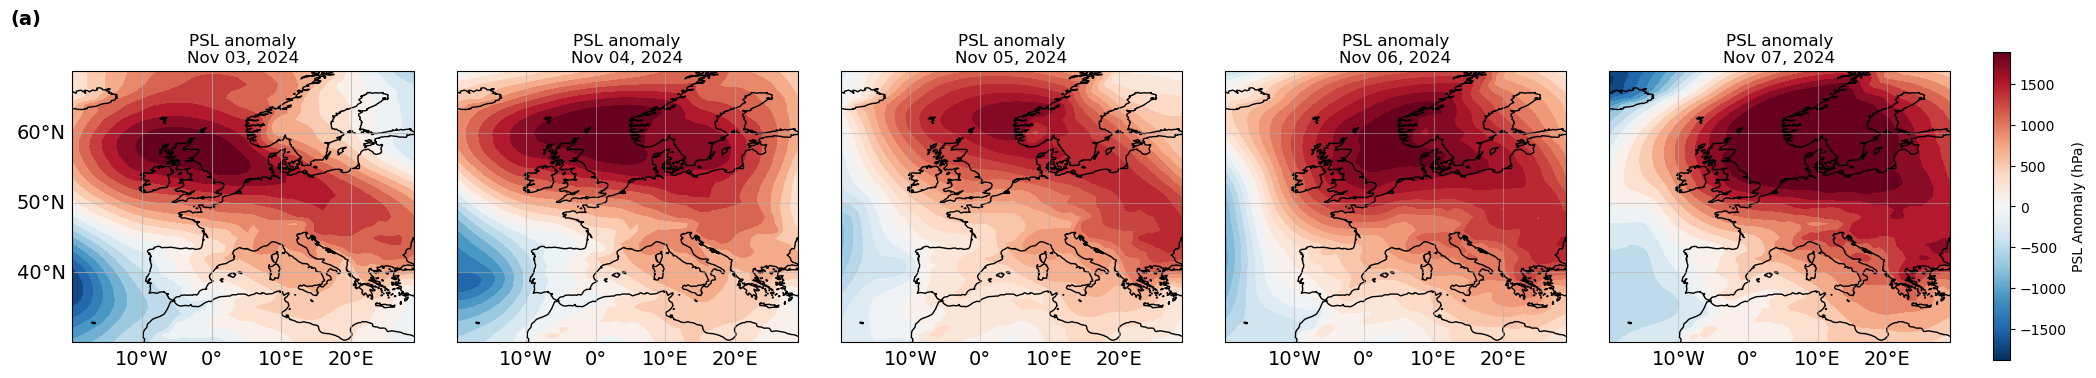

In [ ]:

target_date = pd.to_datetime(LEE_dat_ERA5['date_start'].iloc[172])
n_days = 5
dates_to_plot = [target_date - pd.Timedelta(days=d) for d in range(n_days-2, -2, -1)]
# print("dates_to_plot =", dates_to_plot)

cmap_name = "RdBu_r"

# --- select slices from xarray Dataset/DataArray (assumes ts_datasets is an xarray dataset) ---
psl_sel = ts_datasets['psl'].sel(time=dates_to_plot, method='nearest')  # returns DataArray

# convert to numpy and detect units (Pa vs hPa). If values are large (>2000) assume Pa -> divide by 100
psl_slices_hpa = psl_sel.values  # shape expected (ntime, nlat, nlon)

# --- prepare lon/lat grids ---
lon_vals = ((ts_datasets['lon'].values + 180) % 360) - 180
lat_vals = ts_datasets['lat'].values
# ensure ordering of lat/lon matches psl array (psl likely lat x lon)
# print("lon shape", lon_vals.shape, "lat shape", lat_vals.shape)
Lon2d, Lat2d = np.meshgrid(lon_vals, lat_vals)  # Lon2d,Lat2d shapes: (nlat, nlon)

# --- plotting ---
ncols = psl_slices_hpa.shape[0]  # number of times (should be n_days)
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

vmin = np.nanmin(psl_slices_hpa)
vmax = -vmin

cmap_used = None
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
    z = psl_slices_hpa[i, :, :]  

    cf = ax.contourf(
        Lon2d, Lat2d, z,
        levels=21, vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()

    setup_gridlines(ax, deg=10, alpha=0.7 if i==0 else 0.5, ll=(i==0))

    title_time = dates_to_plot[i]

    ax.set_title(pd.to_datetime(title_time).strftime("%b %d, %Y"), fontsize=12)

# (a) label
fig.text(0.1, 0.95, "(a)", fontsize=14)

# colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
